# 1. Giới thiệu về dự án

Dự án tập trung vào việc xây dựng mô hình học sâu để phân loại giới tính từ hình ảnh gương mặt, với tập dữ liệu gồm 10,000 hình ảnh (8,000 huấn luyện, 1,000 xác thực, 1,000 kiểm tra).  
Mục tiêu là đạt độ chính xác cao trên tập kiểm tra, với định dạng nộp bài là file CSV chứa ID và Label (0 cho nam, 1 cho nữ).  

Mô hình **VGG16** được chọn nhờ khả năng trích xuất đặc trưng mạnh mẽ từ ImageNet, phù hợp cho transfer learning.


# 2. Lý do sử dụng mô hình VGG16

VGG16 là một mạng CNN sâu với 16 lớp, được huấn luyện trước trên ImageNet – bộ dữ liệu lớn chứa hàng triệu hình ảnh.  
Lý do chọn VGG16 bao gồm:

- **Khả năng trích xuất đặc trưng**:  
  Học được các đặc trưng hình ảnh tổng quát, bao gồm đặc trưng gương mặt, phù hợp cho phân loại giới tính.

- **Transfer learning**:  
  Giảm thời gian huấn luyện và yêu cầu dữ liệu, đặc biệt hữu ích với tập 8,000 hình ảnh huấn luyện.

- **Cấu trúc đơn giản**:  
  Kiến trúc tuần tự, dễ tích hợp và điều chỉnh.

- **Hiệu suất đã chứng minh**:  
  Là mô hình phổ biến, đáng tin cậy trong các tác vụ phân loại hình ảnh.

So với ResNet hoặc EfficientNet, **VGG16 cân bằng giữa hiệu suất và tính đơn giản**, rất phù hợp với quy mô dữ liệu hiện có.


## Import thư viện

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping, Callback
from PIL import Image
import os
import numpy as np
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from tensorflow.keras.applications.vgg16 import preprocess_input

2025-06-12 03:44:45.942031: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749699886.167549      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749699886.230233      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Giám sát learning rate và kiểm tra thư mục dữ liệu

In [2]:
class LearningRateLogger(Callback):
    def __init__(self):
        super().__init__()
        self.lr_history = []

    def on_epoch_end(self, epoch, logs=None):
        current_lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        self.lr_history.append(current_lr)
        print(f'Tỷ lệ học cho epoch {epoch}: {current_lr}')
        
# Set up paths to data directories
data_dir  = '/kaggle/input/c/2425-ii-ait-3002-1-gender-classification/Dataset'
train_dir = os.path.join(data_dir, 'Train')
val_dir = os.path.join(data_dir, 'Val')
test_dir = os.path.join(data_dir, 'Test')

# Check if directories exist
for directory in [train_dir, val_dir, test_dir]:
    if not os.path.exists(directory):
        print(f"Không tìm thấy thư mục: {directory}")
        raise FileNotFoundError(f"Thư mục {directory} không tồn tại.")

# 3. Thiết lập Data Augmentation và Data Loader

Trong bước này, chúng ta sẽ:

1. Đặt tham số cơ bản cho ảnh và batch size.  
2. Khởi tạo hai `ImageDataGenerator`—một cho huấn luyện với data augmentation, một cho validation chỉ với tiền xử lý.  
3. Tạo các generator đọc ảnh từ thư mục.  
4. Lấy và in ra tên lớp (class names).


## 3.1 Tham số cơ bản

- **`img_height`, `img_width`**: Kích thước đầu vào của ảnh (224×224).  
- **`batch_size`**: Số ảnh trong mỗi batch (64).  


## 3.2 Tạo ImageDataGenerator cho huấn luyện



In [3]:
# Set basic parameters
img_height, img_width = 224, 224
batch_size = 6

# Create ImageDataGenerator with preprocess_input
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    brightness_range=[0.8, 1.2],
    channel_shift_range=0.1
)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Load data from directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)
validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

# Get class names
class_names = list(train_generator.class_indices.keys())
print("Class indices:", train_generator.class_indices)

Found 8000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Class indices: {'Female': 0, 'Male': 1}


## 5. Trực quan hóa phân phối và ví dụ ảnh

### 5.1 Phân phối số lượng ảnh theo lớp  
Đoạn mã đầu tiên tính số lượng ảnh trong mỗi lớp cho tập huấn luyện và validation, sau đó vẽ biểu đồ cột so sánh:

- **`np.bincount`**: Đếm số ảnh cho mỗi nhãn trong `train_generator.classes` và `validation_generator.classes`.  
- Biểu đồ sử dụng hai cột xen kẽ (train – xanh, val – cam) để thấy rõ chênh lệch hay cân bằng dữ liệu giữa các lớp.  
- Thiết lập tiêu đề, nhãn trục và chú giải, rồi lưu ảnh ra file `data_distribution.png`.

### 5.2 Hiển thị một số ảnh mẫu  
Đoạn mã tiếp theo lấy một batch ảnh đầu tiên từ `train_generator` và hiển thị 5 ảnh bất kỳ:

- **Khôi phục ảnh gốc**: Do `preprocess_input` trừ đi mean, nên cần cộng lại giá trị mean `[103.939, 116.779, 123.68]` và chuyển từ BGR→RGB.  
- **`plt.subplot`**: Sắp xếp 5 ảnh trên một hàng, gỡ bỏ trục tọa độ và đặt tiêu đề nhãn tương ứng (`Label: nam/nữ`).  
- Lưu kết quả ra file `sample_images.png` và hiển thị trực tiếp trong notebook.



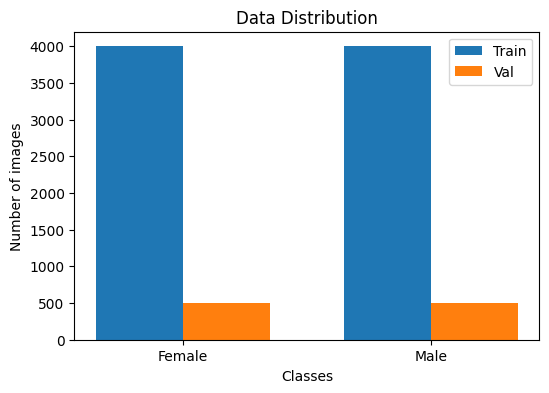

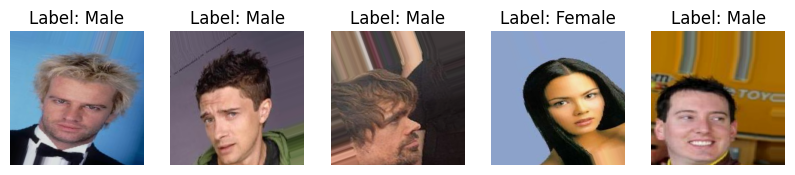

In [4]:
# Plot data distribution
train_counts = np.bincount(train_generator.classes)
val_counts = np.bincount(validation_generator.classes)
x = np.arange(len(class_names))
width = 0.35
plt.figure(figsize=(6, 4))
plt.bar(x - width/2, train_counts, width, label='Train', color='#1f77b4')
plt.bar(x + width/2, val_counts, width, label='Val', color='#ff7f0e')
plt.xlabel('Classes')
plt.ylabel('Number of images')
plt.title('Data Distribution')
plt.xticks(x, class_names)
plt.legend()
plt.savefig('/kaggle/working/data_distribution.png')
plt.show()

# Plot some sample images from the training set
x, y = next(train_generator)
plt.figure(figsize=(10, 10))
for i in range(5):
    plt.subplot(1, 5, i+1)
    img = x[i].copy()
    mean = np.array([103.939, 116.779, 123.68])
    img += mean
    img = img[:, :, ::-1]  # BGR to RGB
    img = np.clip(img, 0, 255).astype(np.uint8)
    plt.imshow(img)
    plt.title(f'Label: {class_names[int(y[i])]}')
    plt.axis('off')
plt.savefig('/kaggle/working/sample_images.png')
plt.show()

## 6. Tính class weights, xây dựng mô hình & callbacks

1. **Tính class weights**  
   - Sử dụng `compute_class_weight` để cân bằng ảnh hưởng của từng lớp dựa trên tần suất xuất hiện trong `train_generator.classes`.  
   - Kết quả được lưu thành dict `class_weight_dict` để truyền vào `model.fit(...)`.

2. **Tải và “đóng băng” VGG16 giai đoạn 1**  
   - Khởi tạo `base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))`.  
   - Đặt `layer.trainable = False` cho toàn bộ các layer trong VGG16, chỉ sử dụng khả năng trích xuất đặc trưng.

3. **Xây dựng phần đầu (head) của mô hình**  
   - Gồm các lớp:  
     - `Flatten()` → `Dropout(0.3)`  
     - `Dense(512, relu)` → `BatchNormalization()` → `Dropout(0.5)`  
     - `Dense(256, relu)` → `BatchNormalization()` → `Dropout(0.5)`  
     - `Dense(1, sigmoid)`  
   - Kết hợp với `base_model` thành `Sequential([...])`.

4. **Biên dịch mô hình Phase 1**  
   - Optimizer: `AdamW(lr=1e-4, weight_decay=1e-4, clipnorm=1.0)`.  
   - Loss: `binary_crossentropy`.  
   - Metrics: `accuracy`.

5. **Định nghĩa callbacks**  
   - `ReduceLROnPlateau`: giảm lr khi `val_loss` không cải thiện (factor 0.2, patience 2).  
   - `ModelCheckpoint`: lưu phiên bản tốt nhất theo `val_accuracy`.  
   - `EarlyStopping`: dừng sớm nếu `val_accuracy` không tăng trong 40 epoch.  
   - `LearningRateLogger`: theo dõi và in ra learning rate sau mỗi epoch.



In [5]:
# Compute class weights
classes = np.unique(train_generator.classes)
class_weights = compute_class_weight('balanced', classes=classes, y=train_generator.classes)
class_weight_dict = dict(zip(classes, class_weights))
print("Class weights:", class_weight_dict)

# Load VGG16 model with pre-trained weights
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# Phase 1: Freeze entire VGG16
for layer in base_model.layers:
    layer.trainable = False

# Build new model
model = Sequential([
    base_model,
    Flatten(),
    Dropout(0.4),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.6),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.6),
    Dense(1, activation='sigmoid')
])

# Compile model for Phase 1
model.compile(optimizer=AdamW(learning_rate=0.0001, weight_decay=0.0001, clipnorm=1.0),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Define callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-5, min_delta=0.001)
checkpoint = ModelCheckpoint('/kaggle/working/best_model_improved.h5',
                             monitor='val_accuracy',
                             save_best_only=True,
                             mode='max',
                             verbose=1)
early_stopping = EarlyStopping(monitor='val_accuracy',
                               patience=30,
                               mode='max',
                               verbose=1)
lr_logger = LearningRateLogger()

callbacks = [reduce_lr, checkpoint, early_stopping, lr_logger]


Class weights: {0: 1.0, 1: 1.0}


I0000 00:00:1749699906.121843      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1749699906.122555      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## 7. Huấn luyện mô hình qua 2 giai đoạn

**Phase 1 – Feature Extraction**  
- Chạy huấn luyện với toàn bộ lớp VGG16 “đóng băng” (trainable=False) để chỉ cập nhật phần head.  
- Số epoch: 300, batch size: 64, steps per epoch và validation steps được tính từ tổng số ảnh.  
- Sử dụng `class_weight_dict` để cân bằng đóng góp của mỗi lớp.  
- Áp dụng các callbacks đã định nghĩa (giảm LR, lưu checkpoint, dừng sớm, ghi nhận LR).

**Phase 2 – Fine‐tuning một số block cuối**  
- Mở trainable cho các layer thuộc block3, block4 và block5 của VGG16, vẫn giữ block1–2 “đóng băng”.  
- Biên dịch lại model với learning rate thấp hơn (1e-5) để tránh phá vỡ các đặc trưng đã học.  
- Tiếp tục huấn luyện thêm 300 epoch với cùng thiết lập generators, callbacks và class weights.

Qua hai giai đoạn này, model tận dụng tối đa kiến thức của VGG16 ở phase 1 và sau đó điều chỉnh sâu hơn các tầng cao cấp để tăng độ chính xác phân loại.  


In [6]:
# Train Phase 1
history_phase1 = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=300,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

# Phase 2: Unfreeze block3, block4, and block5
for layer in base_model.layers:
    if 'block3' in layer.name or 'block4' in layer.name or 'block5' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

# Recompile model with lower learning rate
model.compile(optimizer=AdamW(learning_rate=0.00001, weight_decay=0.0001, clipnorm=1.0),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train Phase 2
history_phase2 = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=300,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/300


I0000 00:00:1749699912.417204      80 service.cc:148] XLA service 0x784b3c006de0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749699912.418341      80 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1749699912.418369      80 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1749699913.147549      80 cuda_dnn.cc:529] Loaded cuDNN version 90300


   2/1333 ━━━━━━━━━━━━━━━━━━━━ 1:30 68ms/step - accuracy: 0.5833 - loss: 0.9394  

I0000 00:00:1749699919.418518      80 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1333/1333 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.6879 - loss: 0.7143
Epoch 1: val_accuracy improved from -inf to 0.92169, saving model to /kaggle/working/best_model_improved.h5
Tỷ lệ học cho epoch 0: 9.999999747378752e-05
1333/1333 ━━━━━━━━━━━━━━━━━━━━ 166s 116ms/step - accuracy: 0.6879 - loss: 0.7142 - val_accuracy: 0.9217 - val_loss: 0.2266 - learning_rate: 1.0000e-04
Epoch 2/300
   1/1333 ━━━━━━━━━━━━━━━━━━━━ 43s 32ms/step - accuracy: 0.8333 - loss: 0.1607

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.92169 to 0.92269, saving model to /kaggle/working/best_model_improved.h5
Tỷ lệ học cho epoch 1: 9.999999747378752e-05
1333/1333 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8333 - loss: 0.1607 - val_accuracy: 0.9227 - val_loss: 0.2269 - learning_rate: 1.0000e-04
Epoch 3/300
1333/1333 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.8192 - loss: 0.5034
Epoch 3: val_accuracy did not improve from 0.92269
Tỷ lệ học cho epoch 2: 9.999999747378752e-05
1333/1333 ━━━━━━━━━━━━━━━━━━━━ 128s 96ms/step - accuracy: 0.8192 - loss: 0.5034 - val_accuracy: 0.9217 - val_loss: 0.2137 - learning_rate: 1.0000e-04
Epoch 4/300
   1/1333 ━━━━━━━━━━━━━━━━━━━━ 1:02 47ms/step - accuracy: 0.8333 - loss: 0.5226
Epoch 4: val_accuracy did not improve from 0.92269
Tỷ lệ học cho epoch 3: 9.999999747378752e-05
1333/1333 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8333 - loss: 0.5226 - val_accuracy: 0.9217 - val_loss: 0.2140 - learning_rate: 1.0000e-04
Epoch 5/300
1333/1333 ━━━

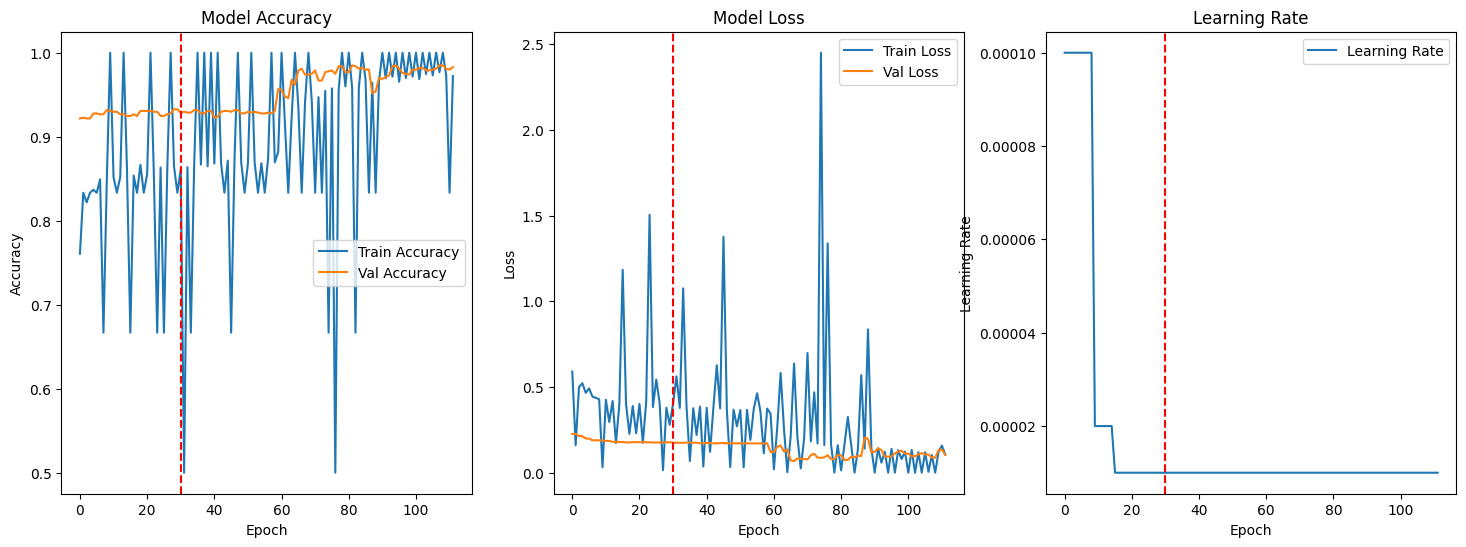

In [7]:

# Plot loss, accuracy, and learning rate
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.plot(history_phase1.history['accuracy'] + history_phase2.history['accuracy'], label='Train Accuracy')
plt.plot(history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.axvline(x=30, color='r', linestyle='--', label='Phase 2 start')

plt.subplot(1, 3, 2)
plt.plot(history_phase1.history['loss'] + history_phase2.history['loss'], label='Train Loss')
plt.plot(history_phase1.history['val_loss'] + history_phase2.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.axvline(x=30, color='r', linestyle='--')

plt.subplot(1, 3, 3)
plt.plot(lr_logger.lr_history, label='Learning Rate')
plt.title('Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.legend()
plt.axvline(x=30, color='r', linestyle='--')

plt.savefig('/kaggle/working/training_metrics_with_lr.png')
plt.show()


## 8. Trực quan hóa quá trình huấn luyện

Phần này hiển thị đồng thời ba biểu đồ—độ chính xác, mất mát và learning rate—qua toàn bộ hai giai đoạn huấn luyện:

- **Biểu đồ Accuracy**  
  - Đường xanh: độ chính xác trên tập huấn luyện (train_accuracy).  
  - Đường cam: độ chính xác trên tập validation (val_accuracy).  
  - Đường gạch đỏ dọc (x=30): đánh dấu thời điểm bắt đầu Phase 2.

- **Biểu đồ Loss**  
  - Đường xanh: mất mát huấn luyện (train_loss).  
  - Đường cam: mất mát validation (val_loss).  
  - Đường gạch đỏ dọc (x=30): thời điểm chuyển sang fine-tuning.

- **Biểu đồ Learning Rate**  
  - Đường thể hiện lịch sử learning rate (`lr_logger.lr_history`) sau mỗi epoch.  
  - Giúp dễ dàng quan sát cơ chế giảm LR (ReduceLROnPlateau) và các điều chỉnh qua callback.  
  - Đường gạch đỏ dọc (x=30) tương ứng với mốc bắt đầu Phase 2.

> Kết quả lưu thành ảnh `training_metrics_with_lr.png` và hiển thị trực tiếp để bạn so sánh hiệu quả huấn luyện trước và sau khi unfreeze các block của VGG16.


167/167 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - accuracy: 0.9805 - loss: 0.1418
Độ chính xác trên tập validation (mô hình cuối cùng): 0.9819999933242798
167/167 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.9815 - loss: 0.0970
Độ chính xác trên tập validation (mô hình tốt nhất): 0.984000027179718
167/167 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step


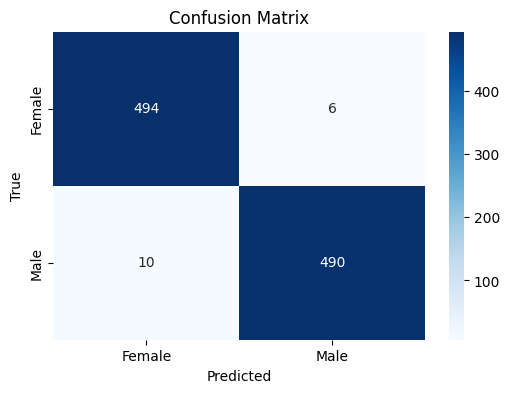

Classification Report:
              precision    recall  f1-score   support

      Female       0.98      0.99      0.98       500
        Male       0.99      0.98      0.98       500

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



In [8]:
# Evaluate model on validation set
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f'Độ chính xác trên tập validation (mô hình cuối cùng): {val_accuracy}')

# Load best model
best_model = tf.keras.models.load_model('/kaggle/working/best_model_improved.h5')

# Evaluate best model
best_val_loss, best_val_accuracy = best_model.evaluate(validation_generator)
print(f'Độ chính xác trên tập validation (mô hình tốt nhất): {best_val_accuracy}')

# Predict on validation set for confusion matrix
y_pred = best_model.predict(validation_generator)
y_pred_classes = (y_pred > 0.5).astype(int).flatten()
y_true = validation_generator.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig('/kaggle/working/confusion_matrix.png')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))


## 9. Đường cong ROC & Phân tích mẫu phân loại sai

- **ROC Curve**  
  Tính toán FPR (False Positive Rate), TPR (True Positive Rate) và AUC (Area Under Curve) từ kết quả dự đoán. Vẽ đồ thị ROC để đánh giá khả năng phân biệt giữa hai lớp ở các ngưỡng khác nhau, lưu thành `roc_curve.png` và in giá trị AUC ra console.

- **Phân tích mẫu bị phân loại sai**  
  Xác định chỉ số của các ảnh trong tập validation mà mô hình dự đoán không chính xác. Lấy tối đa 20 ảnh mẫu, hiển thị theo lưới (5×4), mỗi ảnh kèm tiêu đề “True: … / Pred: …” và lưu thành `misclassified_samples.png`. Nếu không có mẫu nào bị sai, chương trình sẽ in thông báo “Không có mẫu nào bị phân loại sai.”


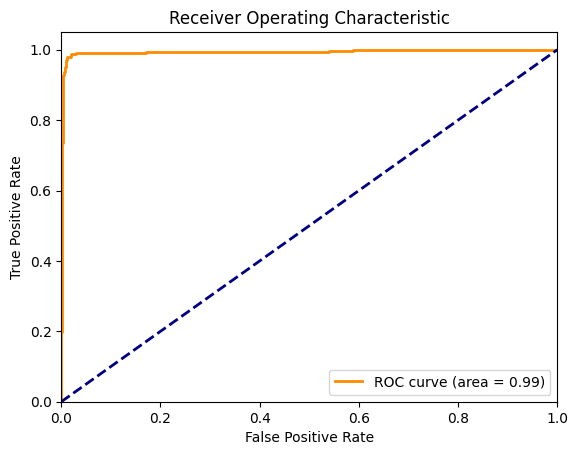

AUC: 0.9932


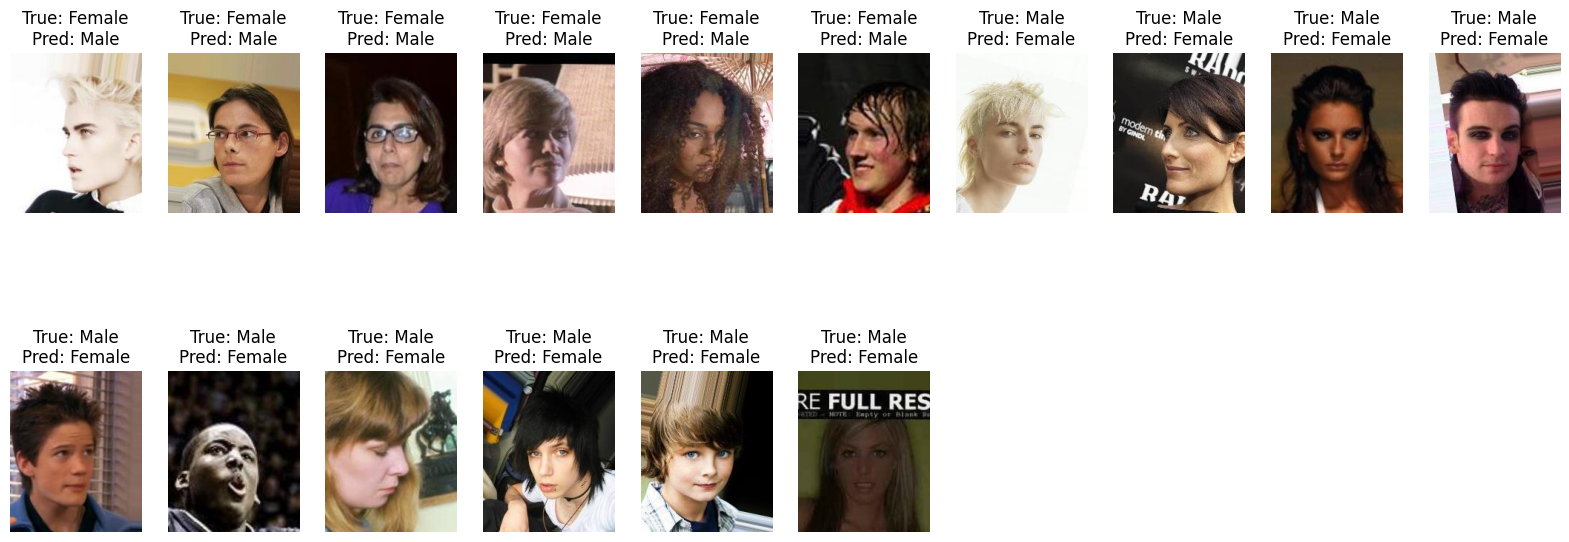

In [9]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.savefig('/kaggle/working/roc_curve.png')
plt.show()
print(f'AUC: {roc_auc:.4f}')

# Plot misclassified images
misclassified_idx = np.where(y_pred_classes != y_true)[0]
if len(misclassified_idx) > 0:
    val_filenames = validation_generator.filenames
    val_full_paths = [os.path.join(val_dir, fname) for fname in val_filenames]
    plt.figure(figsize=(20,20))
    for i, idx in enumerate(misclassified_idx[:20]):
        path = val_full_paths[idx]
        img = Image.open(path)
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred_classes[idx]]
        plt.subplot(5,10,i+1)
        plt.imshow(img)
        plt.title(f'True: {true_label}\nPred: {pred_label}')
        plt.axis('off')
    plt.savefig('/kaggle/working/misclassified_samples.png')
    plt.show()
else:
    print("Không có mẫu nào bị phân loại sai.")

## 10. Chuẩn bị dữ liệu test và tạo file submission

Trước khi dự đoán:
- Liệt kê và sắp xếp tất cả file `.jpg` trong thư mục test.  
- Định nghĩa hàm `load_and_preprocess_image` để:
  - Resize ảnh về kích thước `(img_width, img_height)`.  
  - Chuyển thành numpy array và áp dụng hàm `preprocess_input`.

Tiếp theo:  
- Tạo mảng `test_data` chứa tất cả ảnh đã tiền xử lý.  
- Dùng `best_model.predict` để sinh xác suất và chuyển sang nhãn nhị phân với ngưỡng 0.5.  
- Đảo nhãn (`1 - predicted_classes`) nếu cần phù hợp yêu cầu.  
- Tạo DataFrame gồm:
  - `ID`: tên file (không kèm phần mở rộng).  
  - `Label`: nhãn dự đoán cuối cùng.  
- Ghi ra file CSV `submission_improved.csv` để nộp kết quả.


In [10]:
# Load and preprocess test data
test_images = sorted([os.path.join(test_dir, fname) for fname in os.listdir(test_dir) if fname.endswith('.jpg')])

def load_and_preprocess_image(path):
    img = Image.open(path)
    img = img.resize((img_width, img_height))
    img = np.array(img)
    img = preprocess_input(img)
    return img

test_data = np.array([load_and_preprocess_image(path) for path in test_images])

# Predict on test set
predictions = best_model.predict(test_data)
predicted_classes = (predictions > 0.5).astype(int).flatten()
submission_labels = 1 - predicted_classes  # Invert labels

# Create submission file
ids = [os.path.splitext(os.path.basename(path))[0] for path in test_images]
submission = pd.DataFrame({
    'ID': ids,
    'Label': submission_labels
})
submission.to_csv('/kaggle/working/submission_improved.csv', index=False)
print("File submission_improved.csv đã được tạo.")

32/32 ━━━━━━━━━━━━━━━━━━━━ 28s 440ms/step
File submission_improved.csv đã được tạo.
